In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy import units as u
from astropy.coordinates import SkyCoord
#import ogle_utils as ou

In [2]:
y_half = 2.3787; x_half=2.5078

In [3]:
# Get LS4 field centers 
flds = []
for b in [-6, -4]:
    for l in range(-18, 20, 2):
        flds.append([l,b])
for b in [-2, 0, 2]:
    for l in range(-70, 36, 2):
        flds.append([l,b])
for b in [4, 6]:
    for l in range(-18, 20, 2):
        flds.append([l,b])
print(len(flds), (36+72)*8 + (20+20)*4*2)

235 1184


In [4]:
# Given a plot pl, plot an ls4 FOV centered at x,y
def ls4_outline(pl, x,y,x_off=0,y_off=0,color='gray', label=None, rot=0, fill=False, outline=True, center=False, letters=False):
    x_off = np.array([-x_half, -x_half, x_half, x_half, -x_half])
    y_off = np.array([-y_half, y_half, y_half, -y_half, -y_half])
    x_mids = np.array([-x_half, 0, x_half, 0])
    y_mids = np.array([0, y_half, 0, -y_half])
    pts = np.transpose([x_off,y_off])
    pts_mid = np.transpose([x_mids,y_mids])
    r_pts = []; m_pts = []
    ang=rot*np.pi/180
    for pt in pts:
        r_pts.append([pt[0]*np.cos(ang)-pt[1]*np.sin(ang) + x, pt[0]*np.sin(ang)+pt[1]*np.cos(ang) + y])
    for pt in pts_mid:
        m_pts.append([pt[0]*np.cos(ang)-pt[1]*np.sin(ang) + x, pt[0]*np.sin(ang)+pt[1]*np.cos(ang) + y])
    x_off, y_off = np.transpose(r_pts)
    if center:
        pl.plot(x,y, 'k.')
    if outline:
        pl.plot(x_off, y_off, c=color)
        ml1 = np.transpose([m_pts[0],m_pts[2]])
        ml2 = np.transpose([m_pts[1],m_pts[3]])
        pl.plot(*ml1, c=color, linestyle=':')
        pl.plot(*ml2, c=color, linestyle=':')
    q1x,q1y = np.transpose([r_pts[0], m_pts[0], [x,y], m_pts[-1], r_pts[0]])
    q2x,q2y = np.transpose([r_pts[1], m_pts[1], [x,y], m_pts[0], r_pts[1]])
    q3x,q3y = np.transpose([r_pts[2], m_pts[2], [x,y], m_pts[1], r_pts[2]])
    q4x,q4y = np.transpose([r_pts[3], m_pts[3], [x,y], m_pts[2], r_pts[3]])
    if fill:
        pl.fill(q4x, q4y,c='lightsalmon',alpha=0.2)
        pl.fill(q3x, q3y,c='lemonchiffon',alpha=0.5)
        pl.fill(q2x, q2y,c='skyblue',alpha=0.4)
        pl.fill(q1x, q1y,c='lemonchiffon',alpha=0.5)
    if letters:
        pl.text(np.mean(q1x[:-1]), np.mean(q1y[:-1]), 'i', ha='center',va='center')        
        pl.text(np.mean(q2x[:-1]), np.mean(q2y[:-1]), 'g', ha='center',va='center')
        pl.text(np.mean(q3x[:-1]), np.mean(q3y[:-1]), 'i', ha='center',va='center')
        pl.text(np.mean(q4x[:-1]), np.mean(q4y[:-1]), 'z', ha='center',va='center')

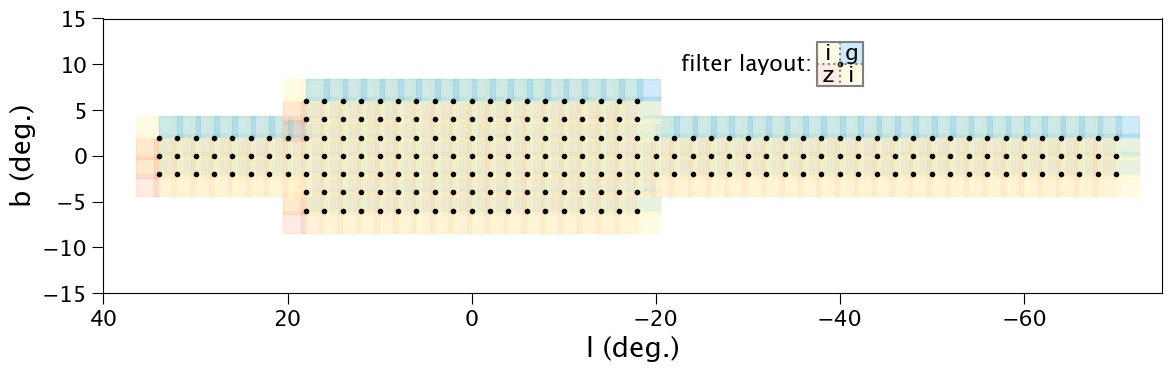

In [5]:
plt.figure(figsize=(12,4))
for l,b in flds:
    ls4_outline(plt, l,b, fill=True, outline=False, rot=0,center=True)
ls4_outline(plt, -40,10, center=True, outline=True, fill=True, letters=True)
plt.text(-37, 10, 'filter layout:', va='center',ha='right')

plt.xlim(40,-75)
plt.ylim(-15,15)
plt.ylabel('b (deg.)'); plt.xlabel('l (deg.)')
plt.tight_layout()
plt.savefig('ls4_galactic_fields_filtercoverage_PA0.png')

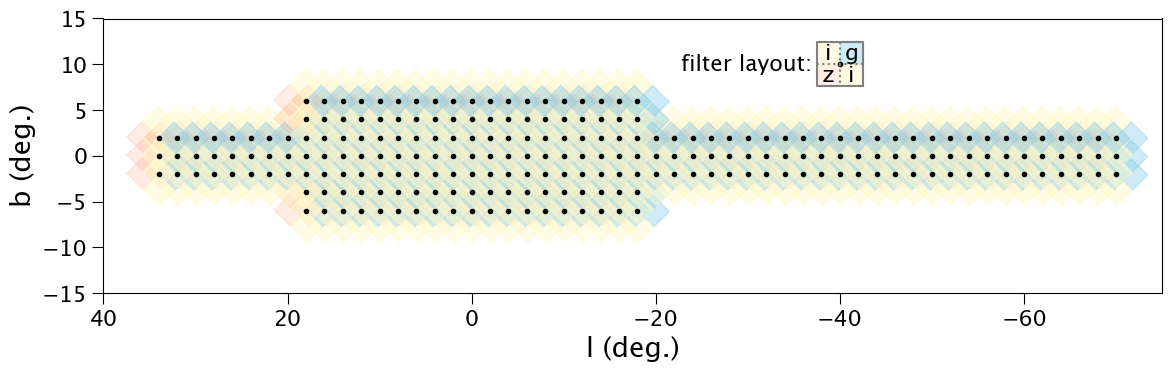

In [6]:
plt.figure(figsize=(12,4))
for l,b in flds:
    ls4_outline(plt, l,b, fill=True, outline=False, rot=45,center=True)
ls4_outline(plt, -40,10, center=True, outline=True, fill=True, letters=True)
plt.text(-37, 10, 'filter layout:', va='center',ha='right')

plt.xlim(40,-75)
plt.ylim(-15,15)
plt.ylabel('b (deg.)'); plt.xlabel('l (deg.)')
plt.tight_layout()
plt.savefig('ls4_galactic_fields_filtercoverage_PA45.png')

In [7]:
def hmsdms(coords):
    strs = []
    for coord in coords:
        ra = coord.ra.to_string(unit=u.hourangle, sep=":", precision=2)
        dec = coord.dec.to_string(unit=u.degree, sep=":", precision=2)
        strs.append([ra,dec])
    return np.transpose(strs)

In [8]:
# Save field centers
ls, bs = np.transpose(flds)
dat = pd.DataFrame(data=flds, columns=("l_degree","b_degree")).sort_values(["l_degree","b_degree"], ignore_index=True)
crds = SkyCoord(l=dat.l_degree*u.degree, b=dat.b_degree*u.degree, frame="galactic").transform_to('icrs')
strs = hmsdms(crds)
dat['ra_hms'] = strs[0]
dat['dec_dms'] = strs[1]
print(dat[:20])

    l_degree  b_degree       ra_hms       dec_dms
0        -70        -2  10:57:42.52  -61:58:55.26
1        -70         0  11:04:31.51  -60:09:34.63
2        -70         2  11:10:37.30  -58:19:03.55
3        -68        -2  11:13:32.47  -62:46:30.94
4        -68         0  11:19:36.65  -60:54:27.74
5        -68         2  11:25:00.37  -59:01:29.90
6        -66        -2  11:30:10.55  -63:27:13.39
7        -66         0  11:35:21.99  -61:32:43.75
8        -66         2  11:39:57.26  -59:37:34.92
9        -64        -2  11:47:32.11  -64:00:30.04
10       -64         0  11:51:43.21  -62:03:55.26
11       -64         2  11:55:24.06  -60:06:55.43
12       -62        -2  12:05:30.40  -64:25:51.70
13       -62         0  12:08:34.42  -62:27:38.08
14       -62         2  12:11:15.63  -60:29:11.20
15       -60        -2  12:23:56.58  -64:42:54.41
16       -60         0  12:25:48.20  -62:43:32.62
17       -60         2  12:27:25.72  -60:44:05.99
18       -58        -2  12:42:40.10  -64:51:21.16


In [9]:
dat.to_csv("field_list.csv", index_label='field_number')
dat.to_latex("field_list.tex", header=["l (deg.)", "b (deg.)","RA (hms)", "Dec (dms)"], column_format="rrrrr", longtable=True)

/var/folders/7d/4v5yjgxj5wd6mxjldjpmv9_h00012p/T/ipykernel_14272/1858687328.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  dat.to_latex("field_list.tex", header=["l (deg.)", "b (deg.)","RA (hms)", "Dec (dms)"], column_format="rrrrr", longtable=True)


In [10]:
def plot_roman_outlines(pl, lbs,color='blue',label=None):
    ol = np.loadtxt('/u/mhuston/code/roman_fields/field_outline.txt',unpack=True)
    use_label=label
    for l,b in lbs:
        pl.plot(l+ol[0], b+ol[1], color=color, label=use_label)
        use_label=None
nominal_roman = np.loadtxt('/u/mhuston/code/roman_fields/field_centers_nominal.txt')

In [11]:
def plot_roman_gps(pl, llim, blim=6, color='k',label=None):
    ls = [llim, 10,10, -10,-10, -llim,-llim, -10,-10, 10,10, llim,llim]
    bs = [2,2, blim,blim, 2,2, -2,-2, -blim,-blim, -2,-2, 2]
    pl.plot(ls,bs, c=color, label=label)

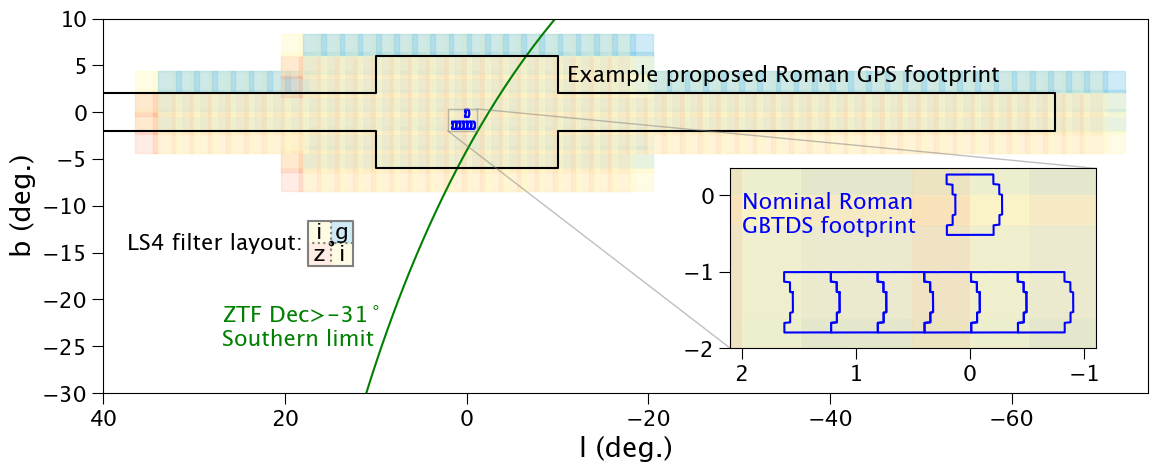

In [19]:
fig, ax = plt.subplots(figsize=(12,5))
for l,b in flds:
    ls4_outline(plt, l,b, fill=True, outline=False, rot=0,center=False)
zras = np.arange(0.0,361.0,1.0)
zlb = SkyCoord(ra=zras, dec=zras*0-31, unit=u.degree, frame='icrs').transform_to('galactic')
zl,zb = zlb.l.degree, zlb.b.degree
zl -= 360*(zl>180)
plt.plot(zl,zb,label=r'ZTF Southern limit (Dec=-31$^\circ$)', color='green')
plot_roman_outlines(plt,nominal_roman, label='Nominal Roman GBTDS footprint')
plot_roman_gps(plt,llim=64.8, blim=6, label='Example proposed Roman GPS footprint')

plt.xlim(-75,40)
plt.ylim(-30,10)
plt.ylabel('b (deg.)'); plt.xlabel('l (deg.)')
#plt.legend(loc=3)
plt.tight_layout()
plt.gca().invert_xaxis()

# im = plt.gcf().add_axes([0.65, 0.22, 0.28, 0.37])
# plot_roman_outlines(im,nominal_roman)
# for l,b in flds:
#     ls4_outline(im, l,b, fill=True, outline=False, rot=0,center=False)
# im.set_ylim(-1.95,0.35)
# im.set_xlim(1.90,-1.1)

axins = ax.inset_axes([0.6, 0.12, 0.35, 0.48],
                     ylim=(-2,0.35), xlim=(-1.1,2.1))
plot_roman_outlines(axins,nominal_roman)
for l,b in flds:
    ls4_outline(axins, l,b, fill=True, outline=False, rot=0,center=False)
ax.indicate_inset_zoom(axins)
axins.invert_xaxis()

ls4_outline(plt, 15,-14, center=True, outline=True, fill=True, letters=True)
plt.text(18, -14, 'LS4 filter layout:', va='center',ha='right')

plt.text(27,-25, r"ZTF Dec>-31$^\circ$"+"\nSouthern limit",c='g')
plt.text(-11,3.2, "Example proposed Roman GPS footprint", c='k')
axins.text(2,-0.5, "Nominal Roman\nGBTDS footprint", c='blue')

plt.savefig('ls4_galactic_fields_othersurveys.png')